This notebook contains the main model for the project. 
The idea is to create a machine learning model for a time series, taht predicts the temperature for a few days. 

The data is the measurements of the temperature and the incoming solar irradiance in an hourly-mean from the weather station at the UniSport in Cologne. The measurement periods were March, April, May of the years, 2024, 2025 and 2026. It was preprocessed from 10min mean to one hour mean and to have only the temperature and the radiation data. 


In [11]:
# Import the needed modules

import pandas as pd 
import numpy as np 
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import pickle 
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [12]:
# Read in the preprocessed data

df=pd.read_csv('data_processed.csv', parse_dates=['TIMESTAMP'])

df

,TIMESTAMP,AirTC_2_Avg,SWUpper_Avg
0,2024-03-01 00:00:00,7.202200,0.000000
1,2024-03-01 01:00:00,6.842833,0.000000
2,2024-03-01 02:00:00,6.663333,0.000000
3,2024-03-01 03:00:00,7.020667,0.000000
4,2024-03-01 04:00:00,7.263167,0.000000
...,...,...,...
6621,2026-05-31 19:00:00,20.578333,4.426333
6622,2026-05-31 20:00:00,19.611667,0.000000
6623,2026-05-31 21:00:00,18.628333,0.000000
6624,2026-05-31 22:00:00,17.856667,0.000000


In [13]:
#normalize data

scale=MinMaxScaler()

df[['AirTC_2_Avg', 'SWUpper_Avg']]=scale.fit_transform(df[['AirTC_2_Avg', 'SWUpper_Avg']])

with open ('scale.pkl', 'wb') as f:
    pickle.dump(scale, f)
 

print(df[['AirTC_2_Avg', 'SWUpper_Avg']].describe())

       AirTC_2_Avg  SWUpper_Avg
count  6626.000000  6626.000000
mean      0.408224     0.179819
std       0.166296     0.253787
min       0.000000     0.000000
25%       0.286057     0.000000
50%       0.395750     0.029450
75%       0.515576     0.302490
max       1.000000     1.000000


In [14]:
#split the data in train und test data

train=df[df['TIMESTAMP'].dt.year.isin([2024, 2025])]
test= df[df['TIMESTAMP'].dt.year==2026]

print(len(train))
print(len(test))

4418
2208


In [15]:
#sliding window

window_size=24  #size of the window
 
def sequences(data):
    X, y=[],[]
    values=data[['AirTC_2_Avg','SWUpper_Avg']].values

    for i in range(len(values)-window_size):
        X.append(values[i:i+window_size])
        y.append(values[i+window_size][0])

    return np.array(X), np.array(y)

X_train, y_train= sequences(train)
X_test, y_test=sequences(test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)



(4394, 24, 2)
(4394,)
(2184, 24, 2)
(2184,)


In [16]:
class WeatherData(Dataset):
    def __init__(self, X, y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)

    def __len__(self):
        return(len(self.X))
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

train_dataset=WeatherData(X_train, y_train)
test_dataset=WeatherData(X_test, y_test)

batch_size=32

train_loader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(test_loader))
print(len(train_loader))


69
138


In [17]:
class FFN(nn.Module):
    def __init__(self):
        super (FFN, self).__init__()

        self.model=nn.Sequential(nn.Linear(24*2,64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))

    
    def forward(self,x):
        x=x.view(x.size(0),-1)
        return self.model(x).squeeze(1)
    

model=FFN()
print(model)


FFN(
  (model): Sequential(
    (0): Linear(in_features=48, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [18]:
crit=nn.MSELoss() #mean squared-error--> how 'wring' is model?

optimizer=optim.Adam(model.parameters(), lr=0.001)  #learning rate


run=50 #

for r in range(run):
    model.train()
    total_loss=0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions=model(X_batch)
        loss=crit(predictions, y_batch)
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    if (r+1)%10==0:
        print((r+1)/run, avg_loss)


0.2 0.0006177640227732533
0.4 0.0005299173250365867
0.6 0.00043603681415729426
0.8 0.00038150109258308277
1.0 0.00040354729904008667


## Comparing the model results with the measurements

In [19]:
model.eval()
predictions=[]
actuals=[]

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred=model(X_batch)
        predictions.extend(pred.numpy())
        actuals.extend(y_batch.numpy())


predictions=np.array(predictions)
actuals=np.array(actuals)


#Mean Absolute error
mae=np.mean(np.abs(predictions-actuals))

#Mean squared error
mse=np.mean((predictions-actuals)**2)


print(f'MAE: {mae}')
print(f'MSE: {mse}')


MAE: 0.019109142944216728
MSE: 0.0005542272119782865


In [20]:
# now convert back to °C for an easier interpretation

with open('scale.pkl', 'rb') as f:
    scale=pickle.load(f)

#transform predictions and measurements back
pred_rescaled=scale.inverse_transform(np.column_stack([predictions, np.zeros(len(predictions))]))[:,0]

actual_rescaled=scale.inverse_transform(np.column_stack([actuals, np.zeros(len(actuals))]))[:,0]



#Error in °C
mae_c=np.mean(np.abs(pred_rescaled-actual_rescaled))
mse_c=np.mean((pred_rescaled-actual_rescaled)**2)
rmse_c=np.sqrt(mse_c) #root mean squared error


print(f'MAE: {mae_c} °C')
print(f'MSE: {mse_c} °C')
print(f'RMSE: {rmse_c} °C')

MAE: 0.6341782729138031 °C
MSE: 0.6104192905399681 °C
RMSE: 0.7812933447431689 °C


<function matplotlib.pyplot.show(close=None, block=None)>

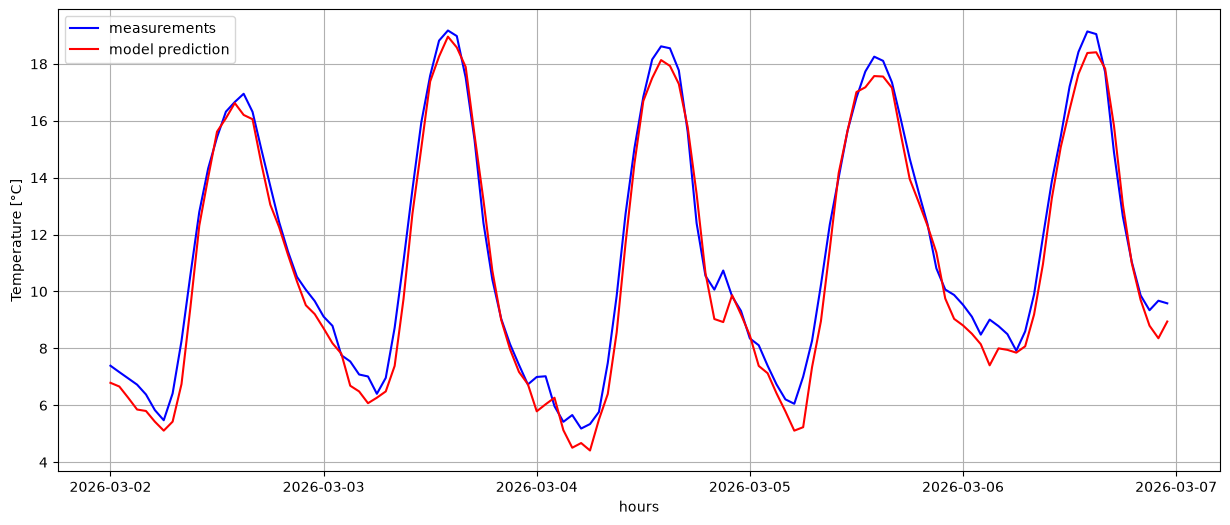

In [28]:
#plot the model forecast vs the real measurements for specific days to see the differences

#for better visualisation: real dates instead of hours
test_timestamps = test["TIMESTAMP"].iloc[window_size:].values


# first:  5 days in a row = 120 hours, starting on first model data
n=120


plt.figure(figsize=(15, 6))
plt.plot(test_timestamps[:n], actual_rescaled[:n], label='measurements', color='blue') #unit: °C
plt.plot(test_timestamps[:n],pred_rescaled [:n], label='model prediction', color='red')
plt.xlabel('hours')
plt.ylabel('Temperature [°C]')
plt.legend()
plt.grid()
plt.show




In [46]:
#Lets go into detail, an look, which dates (per day) were quite good predicted and which ones not:

#build Dataframe
results=pd.DataFrame({'timestamp':test_timestamps, 'measurements':actual_rescaled, 'model prediction':pred_rescaled, 'error absolute':np.abs(pred_rescaled-actual_rescaled)})

#date as own coloumn

results['date']=pd.to_datetime(results['timestamp']).dt.date

#define threshold for good predicitons. above, the predicitons are too far away from measurements
threshold=0.7 #unit:°C

daily=results.groupby('date').agg(
    mae=('error absolute', 'mean'),  #mean error
    max_error=('error absolute', 'max'), #biggest error
    good_pred=('error absolute', lambda x: (x<threshold).sum()), #amount of 'good' predictions
    number_pred=('error absolute', 'count')) #number of predicitions, should be 24 -> 24 hours a day

daily['accuracy']=(daily['good_pred']/daily['number_pred']*100).round(2)

print(daily)


                 mae  max_error  good_pred  number_pred  accuracy
date                                                             
2026-03-02  0.522715   1.516516         19           24     79.17
2026-03-03  0.500731   1.340348         17           24     70.83
2026-03-04  0.678559   1.812012         14           24     58.33
2026-03-05  0.554412   1.775063         16           24     66.67
2026-03-06  0.624608   1.607666         14           24     58.33
...              ...        ...        ...          ...       ...
2026-05-27  0.871078   1.925636          8           24     33.33
2026-05-28  0.737603   1.359760         11           24     45.83
2026-05-29  1.143264   1.833945          4           24     16.67
2026-05-30  1.030868   1.884412          8           24     33.33
2026-05-31  0.509971   1.372673         19           24     79.17

[91 rows x 5 columns]


In [47]:
#Maximum and Minimum of the accuracy
#max=daily.where(daily['accuracy'].max())

print('max of accuracy', daily['accuracy'].max())
print('min of accuracy', daily['accuracy'].min())



max of accuracy 100.0
min of accuracy 16.67
